# Szenendefinition und weitere Funktionen

Führen Sie die folgenden Schritte aus, um die untenstehenden Definitionen und Funktionen verfügbar zu machen.

# IDS Challenge
# Teilprojekt 03: Inverse Roboterkinematik
## Ergebnisse

### Gruppe: The Newts
### Tutor: Henrik Wieschemeyer

Dies ist Ihr Arbeitsbereich mit einigen bereitgestellten Funktionen. Lesen Sie die Aufgabenbeschreibung und implementieren Sie alle Lösungen hier. Lesen Sie zuerst die Datei „README.ipynb“.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML
import math

# --- Global Parameters for the Robot and Environment ---
L1 = 6.0  # Length of the first robot arm link
L2 = 6.0  # Length of the second robot arm link
L3 = 1.0  # Length of the rope/link holding the gripper attachment point

# Robot Gripper Parameters
GRIPPER_RADIUS = 0.5 # Radius of the robot's gripper (blue sphere/circle for collision)

# Manipulable Object Parameters (the one to be picked and placed)
MANIPULABLE_OBJECT_WIDTH = 2 * GRIPPER_RADIUS
MANIPULABLE_OBJECT_HEIGHT = 2 * GRIPPER_RADIUS

# --- MODIFIED: Obstacles reconfigured to create a horizontal gap ---
# This setup forces the robot to move through the gap between the two obstacles.
OBSTACLES = [
    # Lower barrier (floor of the gap)
    {"x_center": 4.5, "width": 1.0, "height": 3.5, "y_min": 0.0},
    {"x_center": 7.0, "width": 1.0, "height": 3.0, "y_min": 0.0},
    # Upper barrier (ceiling of the gap)
    {"x_center": 5.0, "width": 2.0, "height": 2.0, "y_min": 6.5}
]

# --- Pick and Place Station Parameters ---
PICK_STATION = {"x_center": 2.0, "width": 2.0, "height": 1.0, "y_min": 0.0}
PLACE_STATION = {"x_center": 9.5, "width": 2.0, "height": 1.0, "y_min": 0.0}
PICK_TARGET = np.array([2.0, 1.0])
PLACE_TARGET = np.array([9.5, 1.0]) 

# Initial position of the manipulable object (bottom-center) on the pick station
INITIAL_MANIPULABLE_OBJECT_POS = np.array([PICK_STATION["x_center"], PICK_STATION["y_min"] + PICK_STATION["height"]])

# --- Global State Variables for Animation ---
# These are used to store the pre-calculated path and track the state during the animation.
alpha_path = []
beta_path = []
x_path_dense = []
y_path_dense = []
object_is_picked = False
animation_running = True
# We will draw the object's position based on this variable, which is updated each frame.
current_manipulable_object_pos = INITIAL_MANIPULABLE_OBJECT_POS.copy()

In [24]:
def robot_direct_kinematics(alpha, beta):
    #Ursprung
    u = np.array([0.0, 0.0])

    #Punkt P (Erstes Gelenk)
    x_p = L1 * np.cos(alpha)
    y_p = L1 * np.sin(alpha)
    p = np.array([x_p, y_p])

    #Punkt Q (Zweites Gelenk)
    x_q = x_p + L2 * np.cos(alpha + beta)
    y_q = y_p + L2 * np.sin(alpha + beta)
    q = np.array([x_q, y_q])

    #Punkt R (Seilaufhängung)
    x_r = x_q
    y_r = y_q - L3
    r = np.array([x_r, y_r])

    #Punkt M (Mittelpunkt des Greifers)
    x_m = x_r
    y_m = y_r - GRIPPER_RADIUS
    m = np.array([x_m, y_m])

    #Punkt T (Tool Center Point / Unterste Kante)
    x_t = x_m
    y_t = y_m - GRIPPER_RADIUS
    t = np.array([x_t, y_t])

    return p, q, r, m, t

# Aufgabe 2.1 Visualisierung und Kollisionsprüfung

Führen Sie die folgenden Zellen aus, um die Visualisierung und Animation zu aktivieren.

Implementieren Sie die Funktion `check_collision_circle_rect`, um zu prüfen, ob der kreisförmige Endeffektor mit einem rechteckigen Hindernis kollidiert. Die effizienteste Methode, um zu prüfen, ob ein Kreis ein achsenparalleles Rechteck schneidet, besteht darin, den Punkt auf dem Rechteck zu ermitteln, der dem Kreismittelpunkt am nächsten liegt, und anschließend den Abstand zwischen beiden zu berechnen.

In [14]:
def robot_inverse_kinematics(target_GB):
    pass

In [15]:
def robot_path_points(target_points):
    """
    Converts a list of target [x, y] points into separate NumPy arrays for x and y coordinates,
    interpolating points between targets to create a smooth path.
    """
    if not target_points:
        return np.array([]), np.array([])

    x_coords = [target_points[0][0]]
    y_coords = [target_points[0][1]]

    for i in range(len(target_points) - 1):
        d = np.sqrt((target_points[i][0] - target_points[i+1][0])**2 + \
                    (target_points[i][1] - target_points[i+1][1])**2)
        num_points = max(2, math.ceil(d / (GRIPPER_RADIUS / 2)))
        x_coords.extend(np.linspace(target_points[i][0], target_points[i+1][0], num_points + 1)[1:])
        y_coords.extend(np.linspace(target_points[i][1], target_points[i+1][1], num_points + 1)[1:])

    return np.array(x_coords), np.array(y_coords)

def check_collision_circle_rect(circle_center, circle_radius, rect_x_center, rect_width, rect_height, rect_y_min_val):
    """
    Checks for collision between a circle and a rectangle.
    """
    # Mittelpunkt des Kreises
    cx, cy = circle_center[0], circle_center[1]

    # Rechteckgrenzen 
    rect_x_min = rect_x_center - (rect_width / 2)
    rect_x_max = rect_x_center + (rect_width / 2)
    rect_y_min = rect_y_min_val
    rect_y_max = rect_y_min_val + rect_height

    # Nächstgelegener Punkt auf dem Rechteck zum Kreismittelpunkt
    closest_x = np.clip(cx, rect_x_min, rect_x_max)
    closest_y = np.clip(cy, rect_y_min, rect_y_max)

    # Abstand zwischen dem Kreismittelpunkt und dem nächstgelegenen Punkt auf dem Rechteck
    distance_x = cx - closest_x
    distance_y = cy - closest_y

    # Abstand berechnen mithilfe des Satzes des Pythagoras
    distance_squared = (distance_x ** 2) + (distance_y ** 2)

    return distance_squared < (circle_radius ** 2)

def intersect_segments(p1, p2, p3, p4):
    """
    Checks if two line segments (p1,p2) and (p3,p4) intersect.
    """
    def orientation(p, q, r):
        val = (q[1] - p[1]) * (r[0] - q[0]) - \
              (q[0] - p[0]) * (r[1] - q[1])
        if val == 0: return 0
        return 1 if val > 0 else 2

    def on_segment(p, q, r):
        return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
                q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))

    o1 = orientation(p1, p2, p3)
    o2 = orientation(p1, p2, p4)
    o3 = orientation(p3, p4, p1)
    o4 = orientation(p3, p4, p2)

    if o1 != 0 and o2 != 0 and o3 != 0 and o4 != 0 and o1 != o2 and o3 != o4:
        return True
    if o1 == 0 and on_segment(p1, p3, p2): return True
    if o2 == 0 and on_segment(p1, p4, p2): return True
    if o3 == 0 and on_segment(p3, p1, p4): return True
    if o4 == 0 and on_segment(p3, p2, p4): return True

    return False

def check_line_rect_collision(p1, p2, rect_x_center, rect_width, rect_height, rect_y_min_val):
    """
    Checks for collision between a line segment (p1, p2) and a rectangle.
    """
    rect_x_min = rect_x_center - rect_width / 2
    rect_x_max = rect_x_center + rect_width / 2
    rect_y_min = rect_y_min_val
    rect_y_max = rect_y_min_val + rect_height

    if (rect_x_min <= p1[0] <= rect_x_max and rect_y_min <= p1[1] <= rect_y_max) or \
       (rect_x_min <= p2[0] <= rect_x_max and rect_y_min <= p2[1] <= rect_y_max):
        return True

    rect_corners = [
        np.array([rect_x_min, rect_y_min]),
        np.array([rect_x_max, rect_y_min]),
        np.array([rect_x_max, rect_y_max]),
        np.array([rect_x_min, rect_y_max])
    ]

    if intersect_segments(p1, p2, rect_corners[0], rect_corners[1]): return True
    if intersect_segments(p1, p2, rect_corners[1], rect_corners[2]): return True
    if intersect_segments(p1, p2, rect_corners[2], rect_corners[3]): return True
    if intersect_segments(p1, p2, rect_corners[3], rect_corners[0]): return True

    return False

def robot_draw(ax, alpha, beta, current_manipulable_object_pos_for_drawing):
    """
    Draws the robot, obstacles, pick/place stations, and the manipulable object onto the provided axes.
    """
    # Clear previous drawings from the axis
    ax.clear()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_aspect('equal')

    all_x_coords = [obs["x_center"] + obs["width"]/2 for obs in OBSTACLES] + \
                   [PICK_STATION["x_center"] + PICK_STATION["width"]/2,
                    PLACE_STATION["x_center"] + PLACE_STATION["width"]/2]
    max_x_val = max(all_x_coords)

    all_y_coords = [obs["y_min"] + obs["height"] for obs in OBSTACLES] + \
                   [PICK_STATION["y_min"] + PICK_STATION["height"],
                    PLACE_STATION["y_min"] + PLACE_STATION["height"]]
    max_y_val = max(all_y_coords)

    ax.set_xlim(-L1, max(L1 + L2 + 2, max_x_val + 2.0))
    ax.set_ylim(-1.0, max(L1 + L2 + 2, max_y_val + 2.0))

    baseline_x = np.array([-0.5, max(max_x_val + 2.0, 12.0)])
    baseline_y = np.array([0.0, 0.0])
    ax.plot(baseline_x, baseline_y, '-k')

    NORMAL_LINK_COLOR = [0.2, 0.2, 0.8]
    COLLISION_COLOR = [1.0, 0.0, 0.0]
    STATION_COLOR = [0.6, 0.6, 0.6]
    MANIPULABLE_OBJECT_COLOR = [1.0, 0.0, 0.0]

    link1_color = NORMAL_LINK_COLOR
    link2_color = NORMAL_LINK_COLOR
    link3_color = NORMAL_LINK_COLOR
    robot_gripper_color = [0.0, 0.0, 1.0]

    collided_obstacle_indices = set()
    overall_collision_detected = False

    O = np.array([0.0, 0.0])
    P, Q, G, GC, GB_fk = robot_direct_kinematics(alpha, beta)

    for idx, obs in enumerate(OBSTACLES):
        if check_collision_circle_rect(GC, GRIPPER_RADIUS, obs["x_center"], obs["width"], obs["height"], obs["y_min"]):
            robot_gripper_color = COLLISION_COLOR
            collided_obstacle_indices.add(idx)
            overall_collision_detected = True
        if check_line_rect_collision(O, P, obs["x_center"], obs["width"], obs["height"], obs["y_min"]):
            link1_color = COLLISION_COLOR
            collided_obstacle_indices.add(idx)
            overall_collision_detected = True
        if check_line_rect_collision(P, Q, obs["x_center"], obs["width"], obs["height"], obs["y_min"]):
            link2_color = COLLISION_COLOR
            collided_obstacle_indices.add(idx)
            overall_collision_detected = True
        if check_line_rect_collision(Q, G, obs["x_center"], obs["width"], obs["height"], obs["y_min"]):
            link3_color = COLLISION_COLOR
            collided_obstacle_indices.add(idx)
            overall_collision_detected = True

    for idx, obs in enumerate(OBSTACLES):
        obstacle_x = obs["x_center"] + obs["width"] / 2 * np.array([-1.0, 1.0, 1.0, -1.0, -1.0])
        obstacle_y = np.array([obs["y_min"], obs["y_min"], obs["y_min"] + obs["height"], obs["y_min"] + obs["height"], obs["y_min"]])
        obstacle_fill_color = COLLISION_COLOR if idx in collided_obstacle_indices else [0.0, 1.0, 0.0]
        ax.fill_between(obstacle_x, obstacle_y, facecolor=obstacle_fill_color, alpha=0.7)
        ax.plot(obstacle_x, obstacle_y, '-k')

    pick_x = PICK_STATION["x_center"] + PICK_STATION["width"] / 2 * np.array([-1.0, 1.0, 1.0, -1.0, -1.0])
    pick_y = np.array([PICK_STATION["y_min"], PICK_STATION["y_min"], PICK_STATION["y_min"] + PICK_STATION["height"], PICK_STATION["y_min"] + PICK_STATION["height"], PICK_STATION["y_min"]])
    ax.fill_between(pick_x, pick_y, facecolor=STATION_COLOR, alpha=0.8)
    ax.plot(pick_x, pick_y, '-k')
    ax.text(PICK_STATION["x_center"], PICK_STATION["y_min"] + PICK_STATION["height"] / 2, "PICK",
            horizontalalignment='center', verticalalignment='center', color='black', fontsize=10)

    place_x = PLACE_STATION["x_center"] + PLACE_STATION["width"] / 2 * np.array([-1.0, 1.0, 1.0, -1.0, -1.0])
    place_y = np.array([PLACE_STATION["y_min"], PLACE_STATION["y_min"], PLACE_STATION["y_min"] + PLACE_STATION["height"], PLACE_STATION["y_min"] + PLACE_STATION["height"], PLACE_STATION["y_min"]])
    ax.fill_between(place_x, place_y, facecolor=STATION_COLOR, alpha=0.8)
    ax.plot(place_x, place_y, '-k')
    ax.text(PLACE_STATION["x_center"], PLACE_STATION["y_min"] + PLACE_STATION["height"] / 2, "PLACE",
            horizontalalignment='center', verticalalignment='center', color='black', fontsize=10)

    rect_x_coords = current_manipulable_object_pos_for_drawing[0] + MANIPULABLE_OBJECT_WIDTH / 2 * np.array([-1.0, 1.0, 1.0, -1.0, -1.0])
    rect_y_coords = np.array([current_manipulable_object_pos_for_drawing[1], current_manipulable_object_pos_for_drawing[1],
                              current_manipulable_object_pos_for_drawing[1] + MANIPULABLE_OBJECT_HEIGHT,
                              current_manipulable_object_pos_for_drawing[1] + MANIPULABLE_OBJECT_HEIGHT,
                              current_manipulable_object_pos_for_drawing[1]])
    ax.fill_between(rect_x_coords, rect_y_coords, facecolor=MANIPULABLE_OBJECT_COLOR, alpha=0.9)
    ax.plot(rect_x_coords, rect_y_coords, '-k')

    ax.plot(np.array([O[0], P[0]]), np.array([O[1], P[1]]), color=link1_color)
    ax.plot(np.array([P[0], Q[0]]), np.array([P[1], Q[1]]), color=link2_color)
    ax.plot(np.array([Q[0], G[0]]), np.array([Q[1], G[1]]), color=link3_color)

    t = np.linspace(0.0, 2 * np.pi, 100)
    circle_x = GC[0] + GRIPPER_RADIUS * np.cos(t)
    circle_y = GC[1] + GRIPPER_RADIUS * np.sin(t)
    ax.fill_between(circle_x, circle_y, facecolor=robot_gripper_color)
    ax.plot(circle_x, circle_y, '-k')

    return overall_collision_detected, GB_fk


In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from ipywidgets import interact, FloatSlider

def test_collision_playground(cx, cy):
    # Fixed obstacle parameters for the test environment
    rx, rw, rh, r_ymin = 5.0, 2.0, 4.0, 1.0
    radius = 1.0
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Call the student's function
    is_colliding = check_collision_circle_rect(
        circle_center=[cx, cy], circle_radius=radius,
        rect_x_center=rx, rect_width=rw, rect_height=rh, rect_y_min_val=r_ymin
    )
    
    # Determine color based on their function's response
    rect_color = 'red' if is_colliding else 'green'
    
    # Draw environment items
    rect_xmin = rx - rw / 2
    obstacle = Rectangle((rect_xmin, r_ymin), rw, rh, facecolor=rect_color, alpha=0.6, edgecolor='black')
    gripper = Circle((cx, cy), radius, facecolor='blue', alpha=0.4, edgecolor='black')
    closest_point_marker = Circle((np.clip(cx, rect_xmin, rect_xmin + rw), np.clip(cy, r_ymin, r_ymin + rh)), 0.1, color='orange')
    
    ax.add_patch(obstacle)
    ax.add_patch(gripper)
    ax.add_patch(closest_point_marker)
    
    plt.title(f"Testing Collision Check | Colliding: {is_colliding}\n(Rectangle turns RED on collision detection)")
    plt.show()

# Create interactive sliders for the circle center coordinates
interact(test_collision_playground, 
         cx=FloatSlider(value=2.0, min=0.0, max=10.0, step=0.1, description='Circle X:'),
         cy=FloatSlider(value=5.0, min=0.0, max=10.0, step=0.1, description='Circle Y:'));

interactive(children=(FloatSlider(value=2.0, description='Circle X:', max=10.0), FloatSlider(value=5.0, descri…

In [17]:
def animate(frame_num):
    global object_is_picked, current_manipulable_object_pos, animation_running, ani

    if not animation_running:
        ani.event_source.stop()
        return

    # Joint angles and gripper position
    current_alpha = alpha_path[frame_num]
    current_beta = beta_path[frame_num]
    _, _, _, _, GB_fk = robot_direct_kinematics(current_alpha, current_beta)

    # Distance-based pick/place logic
    if not object_is_picked and np.linalg.norm(GB_fk - PICK_TARGET) < 0.1:
        object_is_picked = True
        print(f"[Frame {frame_num}] PICKED object at {GB_fk}")
    elif object_is_picked and np.linalg.norm(GB_fk - PLACE_TARGET) < 0.1:
        object_is_picked = False
        current_manipulable_object_pos = PLACE_TARGET.copy()
        print(f"[Frame {frame_num}] PLACED object at {PLACE_TARGET}")

    if object_is_picked:
        current_manipulable_object_pos = GB_fk.copy()

    collision, _ = robot_draw(ax, current_alpha, current_beta, current_manipulable_object_pos)

    title = f"Frame {frame_num+1}/{len(alpha_path)} | Object Picked: {object_is_picked}"
    if collision:
        title = "COLLISION DETECTED! Animation Halted."
        animation_running = False
    ax.set_title(title)

def run_pick_and_place_animation(waypoints):
    """
    Takes a list of waypoints and runs the full pick-and-place animation.
    """
    global fig, ax, ani, alpha_path, beta_path, x_path_dense, y_path_dense
    global object_is_picked, animation_running, current_manipulable_object_pos
    global PICK_TARGET_FROM_WAYPOINTS, PLACE_TARGET_FROM_WAYPOINTS

    # --- 1. State Initialization and Validation ---
    alpha_path, beta_path, x_path_dense, y_path_dense = [], [], [], []
    object_is_picked = False
    animation_running = True
    current_manipulable_object_pos = INITIAL_MANIPULABLE_OBJECT_POS.copy()

    if len(waypoints) < 4:
        print("Error: At least 4 waypoints are needed for a pick and place task (e.g., Hover-Pick, Pick, Hover-Place, Place).")
        return

    # --- 2. Path Pre-calculation ---
    print("Interpolating path from waypoints...")
    x_path_dense, y_path_dense = robot_path_points(waypoints)

    print("Pre-calculating Inverse Kinematics for the entire path...")
    for i in range(len(x_path_dense)):
        target_gb = np.array([x_path_dense[i], y_path_dense[i]])
        alpha, beta = robot_inverse_kinematics(target_gb)
        if alpha is None:
            print(f"ERROR: Path is unreachable. IK failed at point {i+1} ({target_gb[0]:.2f}, {target_gb[1]:.2f}).")
            return
        alpha_path.append(alpha)
        beta_path.append(beta)
            
    print("IK pre-calculation successful. Path is reachable.")

    # --- 3. Animation Setup and Execution ---
    print("Starting animation...")
    fig, ax = plt.subplots(figsize=(10, 8))
    ani = FuncAnimation(fig, animate, frames=len(x_path_dense), repeat=False, interval=50)
    
    display(HTML(ani.to_jshtml()))
    plt.close(fig)


# Aufgabe 2.2 Inverse Kinematik

## Bestimmung der Gelenkwinkel aus der Endeffektorposition

Mit der bereits bekannten direkten Kinematik lässt sich der Roboter nur schwer an eine gewünschte Endeffektorposition bewegen. Um die Endeffektorposition $T$ des Roboters zu einer gewünschten Zielposition ($x_T$, $y_T$) zu bewegen, müssen die **Gelenkwinkel** ($\alpha$, $\beta$) in Abhängigkeit dieser Zielposition berechnet werden. Dieser Vorgang wird als **inverse Kinematik** bezeichnet.

Die grundlegende Aufgabe besteht darin, die in der direkten Kinematik festgelegten Beziehungen umzukehren. Basierend auf der gegebenen direkten Kinematik werden die Punkte $R$, $M$ und $T$ durch einfache vertikale Offsets unter Berücksichtigung der Seillänge $L_3$ und des Objektradius $r$ vom Punkt $Q$ abgeleitet. Der erste Schritt der inversen Kinematik besteht daher darin, die Koordinaten des Punktes $Q = (Q_x, Q_y)$ vom gegebenen Zielpunkt $T$ zu bestimmen.


### 1. Bestimmung des effektiven Zielpunkts $Q$

Gegeben sind die Koordinaten des Zielpunkts $T = (x_T, y_T)$:

Der vertikale Versatz von $Q$ zu $T$ beträgt $L_3 + 2r$. Um die Koordinaten von $Q$ zu bestimmen, kehren wir diesen Versatz einfach um:

$$Q_x = x_T$$
$$Q_y = y_T + (L_3 + 2r)$$

Nun dient $Q = (Q_x, Q_y)$ als effektiver Zielpunkt für den Zweigelenkarm ($L_1$, $L_2$).


### 2. Berechnung des Ellenbogenwinkels ($\beta$)

Aus der direkten Kinematik ist die Formel für die Endeffektorposition bereits bekannt:

$$Q_x = L_1 \cos(\alpha) + L_2 \cos(\alpha + \beta)$$
$$Q_y = L_1 \sin(\alpha) + L_2 \sin(\alpha + \beta)$$

Um $\alpha$ aus der Gleichung zu eliminieren, quadrieren und addieren wir beide Gleichungen. Das Ergebnis lautet:

$$Q_x^2 + Q_y^2 = L_1^2 + L_2^2 + 2 L_1 L_2 \cos(\beta)$$

Umformung zur Lösung von $\cos(\beta)$:

$$\cos(\beta) = \frac{Q_x^2 + Q_y^2 - L_1^2 - L_2^2}{2 L_1 L_2}$$

Um $\beta$ zu berechnen, verwenden wir die Arkustangensfunktion. Beachten Sie, dass es für einen gegebenen $\cos(\beta)$ im Allgemeinen zwei mögliche Lösungen für $\beta$ gibt (entsprechend „Ellbogen hoch“ und „Ellbogen runter“). Um die Konfiguration „Ellbogen nach unten“ zu erreichen (wie sie häufig aus Stabilitäts- oder Arbeitsbereichsgründen gewünscht wird), wählen wir einen negativen Wert für $\sin(\beta)$:

$$\sin(\beta) = -\sqrt{1 - \cos^2(\beta)}$$

Anschließend wird $\beta$ mit der Funktion ``atan2`` berechnet, die den Winkel korrekt im entsprechenden Quadranten platziert:

$$\beta = \text{atan2}(\sin(\beta), \cos(\beta))$$

**Wichtiger Hinweis zur Erreichbarkeit**: Liegt der berechnete Wert von $\cos(\beta)$ außerhalb des Bereichs $[-1, 1]$, befindet sich der Zielpunkt $Q$ außerhalb der Reichweite des Roboters.


### 3. Berechnung des Schulterwinkels ($\alpha$)

Nachdem $\beta$ ermittelt wurde, können wir nun den Schultergelenkwinkel $\alpha$ mithilfe eines geometrischen Ansatzes basierend auf der Dreieckskonstruktion berechnen. Berechnen Sie zunächst den Winkel des Vektors vom Ursprung zum Punkt $Q = (Q_x, Q_y)$:

$$\text{atan2}(Q_y,Q_x)$$

Berechnen Sie anschließend einen Korrekturwinkel basierend auf dem Dreieck, das durch die beiden Glieder gebildet wird, und dem Vektor zu $Q$. Diese Korrektur berücksichtigt die Beugung des zweiten Glieds (mit der Länge $L_2$) am Ellbogen mit dem Winkel $\beta$:

$$\text{atan2}(L_2\sin⁡(\beta),L_1+L_2\cos⁡(\beta))$$

Der Schulterwinkel $\alpha$ ergibt sich durch Subtraktion der Korrektur von der Gesamtrichtung zu $Q$:
$$\alpha = \text{atan2}(Q_y, Q_x) - \text{atan2}(L_2 \sin(\beta), L_1 + L_2 \cos(\beta))$$

In [18]:
def robot_inverse_kinematics(target_GB):
    x_t = target_GB[0]
    y_t = target_GB[1]

    #Bestimmung des Zielpunktes Q
    x_q = x_t
    y_q = y_t + (L3 + 2 * GRIPPER_RADIUS)

    #Kosinus von Beta berechnen
    cos_beta = (x_q**2 + y_q**2 - L1**2 - L2**2) / (2 * L1 * L2)

    #Überprüfung: Ist das Ziel im Arbeitsbereich?
    if cos_beta < -1.0 or cos_beta > 1:
        print("Ziel außerhalb des Arbeitsbereiches!")
        return None, None
    
    #Sinus von Beta (Ellenbogenwinkel)
    sin_beta = -np.sqrt(1 - cos_beta**2)

    #Winkel Beat mit arctan berechnen (Ellenbogenwinkel)
    beta = np.arctan2(sin_beta, cos_beta)

    #Alpha berechnen (Schulterwinkel)
    alpha_part1 = np.arctan2(y_q, x_q)
    alpha_part2 = np.arctan2(L2 * sin_beta, L1 + L2 * cos_beta)
    alpha = alpha_part1 - alpha_part2

    return alpha, beta


Jetzt können Sie überprüfen, ob Ihre inverse Kinematik korrekt implementiert ist, indem Sie eine Liste mit zwei Werten einfügen. Der erste Wert entspricht der x-Position des Endeffektors, der zweite der y-Position.

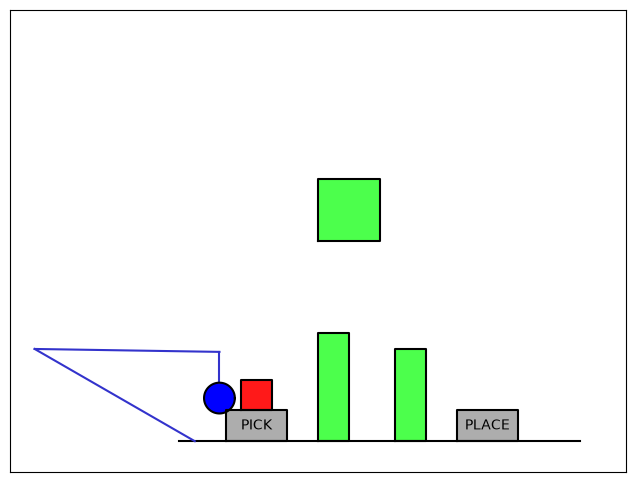

In [19]:
point = [0.8, 0.9]  # Example target point for testing inverse kinematics

alpha, beta = robot_inverse_kinematics(point)
fig, ax = plt.subplots(figsize=(8, 6))
_, _ = robot_draw(ax, alpha, beta, INITIAL_MANIPULABLE_OBJECT_POS)

# Aufgabe 2.3 Sicheren Roboterpfad erstellen 

In diesem Abschnitt definieren Sie den Pfad des Robotergreifers anhand einer Liste von Wegpunkten (**waypoints**). Jeder Wegpunkt ist eine bestimmte $(x, y)$-Koordinate, die der Greifer erreichen muss. Zwischen den von Ihnen angegebenen Wegpunkten wird vom Robotersysten automatisch linear interpoliert.

Die Grundidee ist einfach:

1. **Wegpunkte zum Objekt definieren**: Sie müssen eine Reihe von Punkten erstellen, die den Robotergreifer **über** das zu greifende Objekt und dann **nach unten** zum Objekt führen.

2. **Automatisches Greifen**: Sobald der Greifer die `pick_location` erreicht hat, erkennt das Robotersystem das Objekt automatisch und simuliert das Greifen. Sie müssen keinen Code für die Greifaktion selbst schreiben.

3. **Wegpunkte zum Ablagepunkt definieren:** Nach dem Aufnehmen definieren Sie eine weitere Punktsequenz, um den Roboter mit dem Objekt **über** der `place_location` (wo Sie es ablegen möchten) und anschließend **nach unten** zu diesem Punkt zu bewegen. Planen Sie Ihren Weg so, dass Hindernisse vermieden werden.

4. **Automatisches Platzieren:** Wenn der Greifer die `place_location` erreicht, simuliert das Robotersystem automatisch das Ablegen des Objekts, und es bleibt dort.

Ihre Aufgabe ist es, die `waypoints` mit diesen `[x, y]`-Koordinaten zu definieren. Stellen Sie sich das so vor, als würden Sie den Pfad zeichnen, dem der Greifer folgen soll. Führen Sie anschließend die Funktion `run_pick_and_place_animation(my_waypoints)` aus, um die Animation anzuzeigen.

---

In [22]:
#sichere Höhe für die Lücke zwischen den Hindernissen (zuvor berechnet)
safe_y = 4.0

#Wegpunkte für die Pick-and-Place-Aufgabe definieren
waypoints = [
    # Start: Sicher über dem abzuholenden Objekt positionieren
    [PICK_TARGET[0], safe_y],

    # Greifen: Absenken zum Greifen des Objekts
    [PICK_TARGET[0], PICK_TARGET[1]],

    # Heben: nach dem Greifen wieder auf sichere Höhe anheben
    [PICK_TARGET[0], safe_y],

    # Fahren: Horizontal durch die Lücke zur Ablagepostion
    [PLACE_TARGET[0], safe_y],

    # Absenken: Objekt auf der Ablageposition absetzen
    [PLACE_TARGET[0], PLACE_TARGET[1]],

    # Ende: Nach dem Absetzen wieder auf sichere Höhe hochfahren
    [PLACE_TARGET[0], safe_y]
]           
#Animation starten
run_pick_and_place_animation(waypoints)

Interpolating path from waypoints...
Pre-calculating Inverse Kinematics for the entire path...
IK pre-calculation successful. Path is reachable.
Starting animation...
[Frame 12] PICKED object at [2. 1.]
[Frame 66] PLACED object at [9.5 1. ]
